# SpinLab Getting Started Tutorial

Welcome to the SpinLab getting started tutorial.

This notebook introduces the basic workflow for loading and visualizing EPR data.

The tutorial is designed for new users and assumes minimal Python experience.

## Tutorial Goals

In this notebook we will:

- Load an example EPR dataset
- Inspect the data structure
- Plot the signal
- Perform basic processing
- Discuss common workflows

## About SpinLab

SpinLab is a Python package for EPR and magnetic resonance data processing.

It provides tools for:

- Data loading
- Signal processing
- Visualization
- Spectral analysis
- Workflow automation

## Loading Data

In the next section we will load an example dataset. The dataset is a 3-pulse ESEEM dataset.

The example dataset is included in the repository under the `data/` directory.

In [1]:
# Load example data here, X-band 3pESEEM example experiment

# import required packages
import spinlab as sl

# Define path to data
path = '../data/specman_essem.d01'

data = sl.load(path)

print(data)

values:
	1064 ndarray (complex128)
dims:
	['t']
coords:
	array([3.200e-08, 4.000e-08, 4.800e-08, ..., 8.520e-06, 8.528e-06,
       8.536e-06], shape=(1064,))
attrs:
	'general_version': '1.1'
	'general_demon': '3.5.8602'
	'general_name': '3pESEEM'
	'general_dconfig': 'CNIGM0114rev1.cfg'
	'general_pconfig': 'CNIGM0114rev1.cfp'
	+190 attrs


## Inspecting the Dataset

Once the data is loaded, we can inspect:

- Dimensions
- Axes
- Metadata
- Signal values

In [2]:
# Inspect dataset here

values = data.values

dims = data.dims

coords = data.coords

data.rename('t','t2')

data.coords['t2'] *= 1e6 # convert from s to us

t = data.coords['t2']

print('-'*50)
print('Values:')
print(values)

print('-'*50)
print('Dims:')
print(dims)

print('-'*50)
print('Coords:')
print(coords)

print('-'*50)
print('time axes:')
print(t)

--------------------------------------------------
Values:
[0.22676508-0.01604632j 0.23591952-0.01780682j 0.24531959-0.02017709j ...
 0.23737925-0.02231177j 0.23698491-0.02047756j 0.23580207-0.0194677j ]
--------------------------------------------------
Dims:
['t2']
--------------------------------------------------
Coords:
dims:
['t2']
coords:
[array([0.032, 0.04 , 0.048, ..., 8.52 , 8.528, 8.536], shape=(1064,))]
--------------------------------------------------
time axes:
[0.032 0.04  0.048 ... 8.52  8.528 8.536]


## Plotting the Signal

Visualization is one of the most important parts of EPR data analysis.

We will generate a simple plot of the signal.

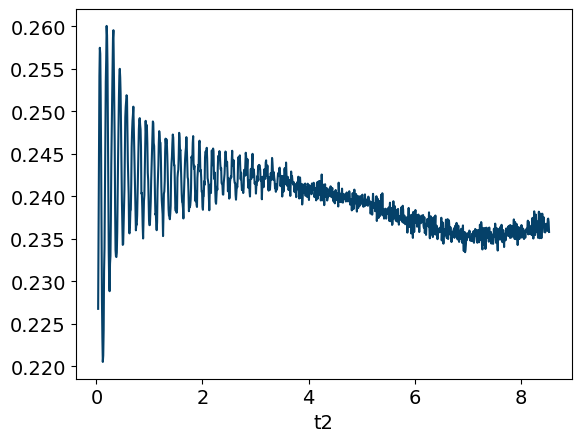

In [3]:
from matplotlib.pylab import plt
plt.rcParams['font.family'] = 'DejaVu Sans'

plt.figure()
sl.plot(data.real)
plt.show()

## Basic Processing

Typical processing operations may include:

- Phase correction
- Baseline correction
- Signal averaging
- Fourier transforms
- Normalization

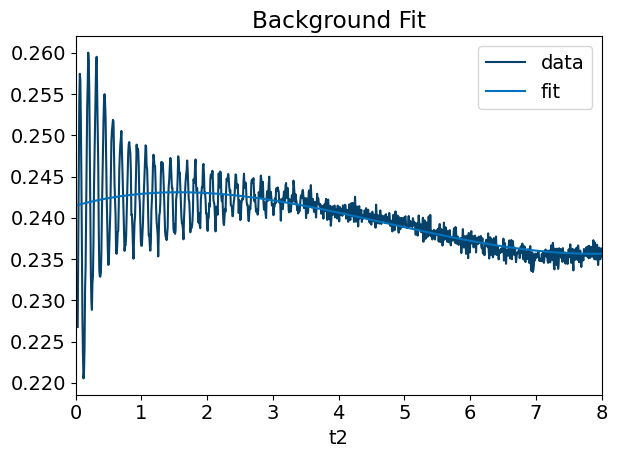

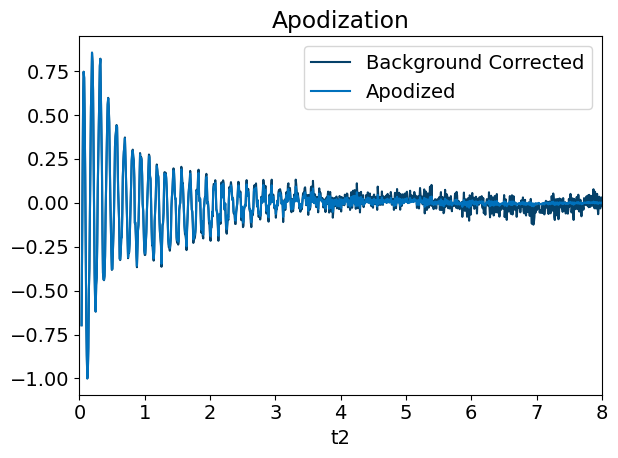

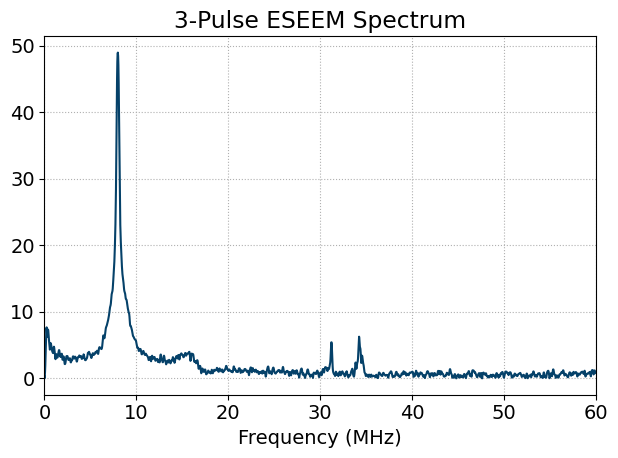

In [14]:
# 3-Pulse ESEEM Processing steps here
import numpy as np

# Select real part
data_real = data.real


background = sl.background(data_real, deg = 3)


plt.figure()
plt.title('Background Fit')
sl.plot(data_real, label = 'data')
sl.plot(background, label = 'fit')
plt.legend()
plt.xlim(0,8)
plt.tight_layout()

# Subtract Background from Data
data_corrected = data_real - background

# Normalize to maximum of absolute value
data_corrected /= np.max(data_corrected.abs)

# Perform apodization with Hamming window function
data_apodized = sl.apodize(data_corrected, kind = 'hamming')


plt.figure()
plt.title('Apodization')
sl.plot(data_corrected, label = 'Background Corrected')
sl.plot(data_apodized, label = 'Apodized')
plt.legend()
plt.xlim(0,8)
plt.tight_layout()

# Fourier Transform data
data_ft = sl.fourier_transform(data_apodized, zero_fill_factor = 4, convert_to_ppm = False)

plt.figure()
plt.title('3-Pulse ESEEM Spectrum')
sl.plot(data_ft.abs)
plt.xlim(0,60)
plt.xlabel('Frequency (MHz)')
plt.grid(linestyle = ":")
plt.tight_layout()
plt.show()

## Summary

In this notebook we introduced the basic SpinLab workflow.

Next tutorials will explore:

- Multi-dimensional datasets
- Echo processing
- Spectral fitting
- Advanced visualization
- Automated analysis pipelines